In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('training.csv')
df_test  = pd.read_csv('testing.csv')


In [3]:
df = pd.concat([df_train, df_test], ignore_index=True)


In [4]:
df

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4957,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,Acne,NaN
4958,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Urinary tract infection,NaN
4959,0,1,0,0,0,0,1,0,0,0,...,0,1,1,1,1,0,0,0,Psoriasis,NaN
4960,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,Impetigo,NaN


In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [6]:
df.tail()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
4957,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4958,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary tract infection
4959,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis
4960,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,Impetigo
4961,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,Fungal infection


In [7]:
df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,...,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000,4962.000000
mean,0.138049,0.160016,0.021967,0.045143,0.021967,0.162233,0.139057,0.045143,0.045143,0.021967,...,0.021967,0.021967,0.021967,0.023378,0.023176,0.023176,0.023176,0.023176,0.023378,0.023176
std,0.344986,0.366658,0.146590,0.207639,0.146590,0.368702,0.346041,0.207639,0.207639,0.146590,...,0.146590,0.146590,0.146590,0.151115,0.150478,0.150478,0.150478,0.150478,0.151115,0.150478
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.nunique()

itching                  2
skin_rash                2
nodal_skin_eruptions     2
continuous_sneezing      2
shivering                2
                        ..
inflammatory_nails       2
blister                  2
red_sore_around_nose     2
yellow_crust_ooze        2
prognosis               41
Length: 133, dtype: int64

In [9]:
prognoses = sorted(df['prognosis'].unique())
prognoses

['(vertigo) Paroymsal  Positional Vertigo',
 'AIDS',
 'Acne',
 'Alcoholic hepatitis',
 'Allergy',
 'Arthritis',
 'Bronchial Asthma',
 'Cervical spondylosis',
 'Chicken pox',
 'Chronic cholestasis',
 'Common Cold',
 'Dengue',
 'Diabetes ',
 'Dimorphic hemmorhoids(piles)',
 'Drug Reaction',
 'Fungal infection',
 'GERD',
 'Gastroenteritis',
 'Heart attack',
 'Hepatitis B',
 'Hepatitis C',
 'Hepatitis D',
 'Hepatitis E',
 'Hypertension ',
 'Hyperthyroidism',
 'Hypoglycemia',
 'Hypothyroidism',
 'Impetigo',
 'Jaundice',
 'Malaria',
 'Migraine',
 'Osteoarthristis',
 'Paralysis (brain hemorrhage)',
 'Peptic ulcer diseae',
 'Pneumonia',
 'Psoriasis',
 'Tuberculosis',
 'Typhoid',
 'Urinary tract infection',
 'Varicose veins',
 'hepatitis A']

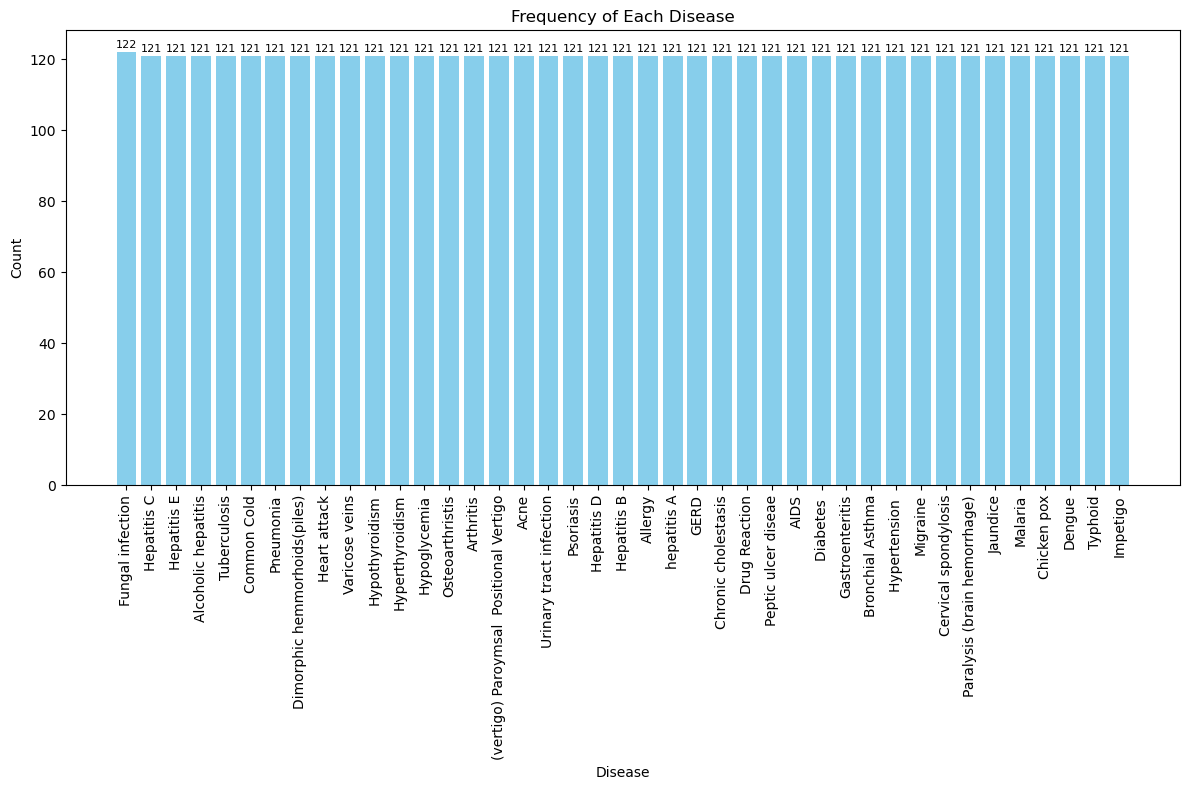

In [10]:
disease_counts = df['prognosis'].value_counts()

plt.figure(figsize=(12, 8))
bars = plt.bar(disease_counts.index, disease_counts.values, color='skyblue')

plt.xticks(rotation=90)

# write each bar with its value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=8)

plt.title("Frequency of Each Disease")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
data = df

In [12]:
# X : Les caractéristiques (symptômes)
X = data.drop(columns=["prognosis"]) 

# y : La cible (les maladies)
y = data[["prognosis"]]  

# Vérification de la forme de X et y
print(X.shape, y.shape)


(4962, 132) (4962, 1)


In [13]:
pd.set_option('display.max_columns', None)
print(data)

      itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  \
0           1          1                     1                    0   
1           0          1                     1                    0   
2           1          0                     1                    0   
3           1          1                     0                    0   
4           1          1                     1                    0   
...       ...        ...                   ...                  ...   
4957        0          1                     0                    0   
4958        0          0                     0                    0   
4959        0          1                     0                    0   
4960        0          1                     0                    0   
4961        1          1                     0                    0   

      shivering  chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  \
0             0       0           0             0        0         

In [14]:
# Vérifier la dispersion des symptômes (features)
feature_variance = X.var()

# Afficher les caractéristiques avec une faible variance (très proches de 0)
low_variance_features = feature_variance[feature_variance == 0]
print("Caractéristiques avec variance 0 (constantes) :")
print(low_variance_features)




Caractéristiques avec variance 0 (constantes) :
fluid_overload    0.0
dtype: float64


In [15]:
# Vérifier si 'fluid_overload' est bien une colonne dans le DataFrame
if 'fluid_overload' in data.columns:
    data = data.drop(columns=['fluid_overload'])
else:
    print("'fluid_overload' n'est pas une colonne dans data.")
    
# Vérifier la forme après la suppression
print("Dim de data après suppression :", data.shape)


Dim de data après suppression : (4962, 132)


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix

# 1) Charger et préparer les données (tu devrais déjà avoir 'data' chargé ailleurs)
#    On suppose que 'data' est un DataFrame pandas contenant 132 colonnes :
#      - 131 colonnes binaires de symptômes (0/1)
#      - 1 colonne 'prognosis' (texte, nom de la maladie)

# 2) Séparer X (symptômes) et y_text (prognosis en texte)
X = data.drop(columns=['prognosis']).values
y_text = data['prognosis'].values  # array de chaînes (41 maladies)

# 3) Encoder y_text en entiers avec LabelEncoder
le = LabelEncoder()
y_int = le.fit_transform(y_text)
#    Maintenant y_int est un array d’entiers dans [0, 40], chacun correspondant à une maladie.

# 4) Fractionner en train / test (20 % test), en stratifiant sur y_int
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X,
    y_int,
    test_size=0.20,
    random_state=42,
    stratify=y_int
)

# 5) (Optionnel) Récupérer y_train et y_test en format texte si besoin d’afficher plus tard
y_train_text = le.inverse_transform(y_train_int)
y_test_text  = le.inverse_transform(y_test_int)

# 6) Afficher les dimensions obtenues
print(f"X_train : {X_train.shape}   (n'échantillons entraînement, n_symptômes)")
print(f"y_train_int : {y_train_int.shape}   (étiquettes entiers)\n")
print(f"X_test  : {X_test.shape}   (n'échantillons test, n_symptômes)")
print(f"y_test_int  : {y_test_int.shape}   (étiquettes entiers)\n")

# 7) Instancier et entraîner le modèle Bernoulli Naïve Bayes
#    - alpha=1.0 (lisser de Laplace) : évite de donner une probabilité nulle si un symptôme n'est jamais vu dans la classe
#    - binarize=None : on part du principe que X est déjà binaire (0/1)
bnb = BernoulliNB(alpha=1.0, binarize=None)
bnb.fit(X_train, y_train_int)

# 8) Faire des prédictions sur le jeu de test
y_pred_int = bnb.predict(X_test)

# 9) Évaluer les performances
print("=== Classification Report (BernoulliNB) ===")
print(classification_report(y_test_int, y_pred_int, target_names=le.classes_, zero_division=0))

# (Optionnel) Afficher la matrice de confusion pour visualiser les confusions entre maladies
cm = confusion_matrix(y_test_int, y_pred_int)
print("\n=== Matrice de confusion ===")
print(cm)



X_train : (3969, 131)   (n'échantillons entraînement, n_symptômes)
y_train_int : (3969,)   (étiquettes entiers)

X_test  : (993, 131)   (n'échantillons test, n_symptômes)
y_test_int  : (993,)   (étiquettes entiers)

=== Classification Report (BernoulliNB) ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        25
          

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define the parameter distribution to sample from
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]  # Fixed 'max_features' from 'auto' to valid options
}

# Instantiate the Random Forest model
clf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Setup RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=100,  # Number of random searches to perform
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=2,  # Show progress
    scoring='accuracy',
    random_state=42
)

# Fit the random search
random_search.fit(X, y_int)

# Best parameters found by RandomizedSearchCV
print(f"Best Parameters: {random_search.best_params_}")

# Evaluate the best model
best_rf_random = random_search.best_estimator_
print("Best Accuracy (Random Forest with RandomizedSearchCV):", random_search.best_score_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 7}
Best Accuracy (Random Forest with RandomizedSearchCV): 0.9997983870967742


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Récupère les meilleurs paramètres
best_params = {
    'n_estimators': 400,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_features': 'log2',
    'max_depth': 7
}

# Réentraîner avec ces paramètres sur X_train, y_train_int
best_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    max_depth=best_params['max_depth'],
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train_int)


RandomForestClassifier(max_depth=7, max_features='log2', min_samples_leaf=2,
                       min_samples_split=10, n_estimators=400, n_jobs=-1,
                       random_state=42)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Prédictions sur X_test
y_pred_test = best_rf.predict(X_test)

# Accuracy finale
print("Final Test Accuracy :", accuracy_score(y_test_int, y_pred_test))

# Rapport détaillé par maladie
print("\n=== Classification Report (final) ===")
print(classification_report(
    y_test_int,
    y_pred_test,
    target_names=le.classes_,
    zero_division=0
))

# Matrice de confusion
print("\n=== Confusion Matrix (final) ===")
print(confusion_matrix(y_test_int, y_pred_test))
# Save the trained model
joblib.dump(best_rf, 'model.joblib')
print("Modèle sauvegardé dans model.joblib")

Final Test Accuracy : 1.0

=== Classification Report (final) ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        25
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold    

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model on the training data
best_rf.fit(X_train, y_train_int)

# Predict on the training set
y_train_pred = best_rf.predict(X_train)

# Calculate the training accuracy
train_accuracy = accuracy_score(y_train_int, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Predict on the test set
y_pred_test = best_rf.predict(X_test)

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test_int, y_pred_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report for the test set
print("\n=== Classification Report (final) ===")
print(classification_report(
    y_test_int,
    y_pred_test,
    target_names=le.classes_,
    zero_division=0
))

# Confusion matrix for the test set
print("\n=== Confusion Matrix (final) ===")
print(confusion_matrix(y_test_int, y_pred_test))


Training Accuracy: 0.9997
Test Accuracy: 1.0000

=== Classification Report (final) ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        25
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                     

In [32]:
pip install scikit-learn==1.5.1


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import joblib

# Charger le modèle sauvegardé
model = joblib.load('./diagnostic_app/model.joblib')

In [ ]:
# If the training accuracy is significantly higher than the test accuracy, it might be a sign of overfitting.(we have the opposite)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1) Instancier le modèle
#    - multi_class='multinomial' pour gérer les 41 classes via softmax
#    - solver='lbfgs' adapté au multinomial
#    - C=1.0 (force de régularisation L2) ; tu peux tester d’autres valeurs
#    - max_iter=1000 pour être sûr que l’optimisation converge
clf_log = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=42
)

# 2) Entraîner sur l’ensemble d’entraînement
clf_log.fit(X_train, y_train_int)

# 3) Prédictions sur l’ensemble de test
y_pred_log = clf_log.predict(X_test)

# 4) Évaluation
print("Accuracy (Logistic Regression) :", accuracy_score(y_test_int, y_pred_log))
print("\n=== Classification Report (Logistic Regression) ===")
print(classification_report(y_test_int, y_pred_log, target_names=le.classes_, zero_division=0))

print("\n=== Matrice de confusion (Logistic Regression) ===")
print(confusion_matrix(y_test_int, y_pred_log))


C:\Users\ASUS\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy (Logistic Regression) : 1.0

=== Classification Report (Logistic Regression) ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        25
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                  